In [107]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lainguyn123/student-performance-factors")

print("Path to dataset files:", path)

Path to dataset files: /Users/stefi/.cache/kagglehub/datasets/lainguyn123/student-performance-factors/versions/9


In [108]:
# Helper: list files in the downloaded dataset folder, pick a supported file and load it
import os
import kagglehub
from kagglehub import KaggleDatasetAdapter

# If the `path` variable isn't available in this notebook session, download the dataset now
try:
    dataset_path
except NameError:
    dataset_path = kagglehub.dataset_download("lainguyn123/student-performance-factors")

print("Dataset folder:", dataset_path)

# Look for supported file extensions
supported_exts = ['.csv', '.tsv', '.json', '.jsonl', '.parquet', '.xlsx', '.xls']
candidates = []
for root, dirs, files in os.walk(dataset_path):
    for f in files:
        if any(f.lower().endswith(ext) for ext in supported_exts):
            candidates.append(os.path.join(root, f))

if not candidates:
    print("No supported data files found in the downloaded dataset.")
else:
    print("Found candidate files:")
    for c in candidates:
        print(' -', c)

    # Prefer CSV/TSV first
    pick = None
    for ext in ('.csv', '.tsv', '.json', '.parquet', '.xlsx'):
        for c in candidates:
            if c.lower().endswith(ext):
                pick = c
                break
        if pick:
            break

    if not pick:
        pick = candidates[0]

    print("Attempting to load:", pick)

    # Use kagglehub to load by giving the relative path if supported, otherwise fall back to pandas
    fname = os.path.relpath(pick, dataset_path)
    try:
        df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "lainguyn123/student-performance-factors", fname)
        print("Loaded with kagglehub, head:")
        print(df.head())
    except Exception as e:
        print("kagglehub.dataset_load failed (falling back to pandas). Error:", e)
        import pandas as pd
        # read directly from the picked file path using pandas based on extension
        if pick.lower().endswith('.csv') or pick.lower().endswith('.tsv'):
            sep = '\t' if pick.lower().endswith('.tsv') else ','
            df = pd.read_csv(pick, sep=sep)
        elif pick.lower().endswith('.json') or pick.lower().endswith('.jsonl'):
            df = pd.read_json(pick, lines=pick.lower().endswith('jsonl'))
        elif pick.lower().endswith('.parquet'):
            df = pd.read_parquet(pick)
        elif pick.lower().endswith('.xlsx') or pick.lower().endswith('.xls'):
            df = pd.read_excel(pick)
        else:
            raise RuntimeError("Don't know how to read file: %s" % pick)

        print("Loaded with pandas, head:")
        print(df.head())

Dataset folder: /Users/stefi/.cache/kagglehub/datasets/lainguyn123/student-performance-factors/versions/9
Found candidate files:
 - /Users/stefi/.cache/kagglehub/datasets/lainguyn123/student-performance-factors/versions/9/StudentPerformanceFactors.csv
Attempting to load: /Users/stefi/.cache/kagglehub/datasets/lainguyn123/student-performance-factors/versions/9/StudentPerformanceFactors.csv
Loaded with kagglehub, head:
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73   

In [109]:
# Check for data issues and calculate relevant metrics for cleaning
print("----- Dataset Info -----")
df.info()

print("\n----- Missing Values (Count) -----")
print(df.isnull().sum())

print("\n----- Duplicate Rows (Count) -----")
print(df.duplicated().sum())

print("\n----- Summary Statistics -----")
display(df.describe(include='all'))

print("\n----- Unique Values per Column (Categorical) -----")
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head(10))
    print("-" * 30)

----- Dataset Info -----
<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
count,6607.000000,6607.000000,6607,6607,6607,6607.00000,6607.000000,6607,6607,6607.000000,6607,6529,6607,6607,6607.000000,6607,6517,6540,6607,6607.000000
unique,NaN,NaN,3,3,2,NaN,NaN,3,2,NaN,3,3,2,3,NaN,2,3,3,2,NaN
top,NaN,NaN,Medium,Medium,Yes,NaN,NaN,Medium,Yes,NaN,Low,Medium,Public,Positive,NaN,No,High School,Near,Male,NaN
freq,NaN,NaN,3362,3319,3938,NaN,NaN,3351,6108,NaN,2672,3925,4598,2638,NaN,5912,3223,3884,3814,NaN
mean,19.975329,79.977448,NaN,NaN,NaN,7.02906,75.070531,NaN,NaN,1.493719,NaN,NaN,NaN,NaN,2.967610,NaN,NaN,NaN,NaN,67.235659
std,5.990594,11.547475,NaN,NaN,NaN,1.46812,14.399784,NaN,NaN,1.230570,NaN,NaN,NaN,NaN,1.031231,NaN,NaN,NaN,NaN,3.890456
min,1.000000,60.000000,NaN,NaN,NaN,4.00000,50.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,55.000000
25%,16.000000,70.000000,NaN,NaN,NaN,6.00000,63.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,65.000000
50%,20.000000,80.000000,NaN,NaN,NaN,7.00000,75.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,67.000000
75%,24.000000,90.000000,NaN,NaN,NaN,8.00000,88.000000,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,69.000000



----- Unique Values per Column (Categorical) -----
Parental_Involvement: 3 unique values
Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64
------------------------------
Access_to_Resources: 3 unique values
Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64
------------------------------
Extracurricular_Activities: 2 unique values
Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64
------------------------------
Motivation_Level: 3 unique values
Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64
------------------------------
Internet_Access: 2 unique values
Internet_Access
Yes    6108
No      499
Name: count, dtype: int64
------------------------------
Family_Income: 3 unique values
Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64
------------------------------
Teacher_Quality: 3 unique values
Teacher_Quali

In [110]:
# Data Cleaning
import pandas as pd
import numpy as np

# 1. Create a copy of the dataframe to avoid working on the original
df_cleaned = df.copy()

# 2. Map categorical to numerical (ordinal) where there's a clear ranking
ordinal_mappings = {
    'Parental_Involvement': {'Low': 0, 'Medium': 1, 'High': 2},
    'Access_to_Resources': {'Low': 0, 'Medium': 1, 'High': 2},
    'Motivation_Level': {'Low': 0, 'Medium': 1, 'High': 2},
    'Family_Income': {'Low': 0, 'Medium': 1, 'High': 2},
    'Teacher_Quality': {'Low': 0, 'Medium': 1, 'High': 2},
    'Distance_from_Home': {'Near': 0, 'Moderate': 1, 'Far': 2},
    'Parental_Education_Level': {'High School': 0, 'College': 1, 'Postgraduate': 2},
    'Peer_Influence': {'Negative': 0, 'Neutral': 1, 'Positive': 2}
}

for col, mapping in ordinal_mappings.items():
    if col in df_cleaned.columns:
        df_cleaned[col + '_ordinal'] = df_cleaned[col].map(mapping)

# 3. Map binary columns to boolean (0/1)
binary_mappings = {
    'Extracurricular_Activities': {'No': 0, 'Yes': 1},
    'Internet_Access': {'No': 0, 'Yes': 1},
    'Learning_Disabilities': {'No': 0, 'Yes': 1},
    'School_Type': {'Public': 0, 'Private': 1},
    'Gender': {'Female': 0, 'Male': 1}
}

for col, mapping in binary_mappings.items():
    if col in df_cleaned.columns:
        df_cleaned[col + '_binary'] = df_cleaned[col].map(mapping)

# 4. Handle missing values (if any were found)
# We will fill missing numeric values with the median, and categorical with the mode
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

cat_cols = df_cleaned.select_dtypes(include=['category', 'str', 'object']).columns
for col in cat_cols:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

print("Data Cleaning Complete.")
print(f"Original shape: {df.shape}, Cleaned shape: {df_cleaned.shape}")

# Let's peek at the newly created numerical columns mapping
print("\nSample of mapped columns:")
mapped_cols = [c for c in df_cleaned.columns if c.endswith('_ordinal') or c.endswith('_binary')]
display(df_cleaned[mapped_cols].head())

Data Cleaning Complete.
Original shape: (6607, 20), Cleaned shape: (6607, 33)

Sample of mapped columns:


,Parental_Involvement_ordinal,Access_to_Resources_ordinal,Motivation_Level_ordinal,Family_Income_ordinal,Teacher_Quality_ordinal,Distance_from_Home_ordinal,Parental_Education_Level_ordinal,Peer_Influence_ordinal,Extracurricular_Activities_binary,Internet_Access_binary,Learning_Disabilities_binary,School_Type_binary,Gender_binary
0,0,2,0,0,1.0,0.0,0.0,2,0,1,0,0,1
1,0,1,0,1,1.0,1.0,1.0,0,0,1,0,0,0
2,1,1,1,1,1.0,0.0,2.0,1,1,1,0,0,1
3,0,1,1,1,1.0,1.0,0.0,0,1,1,0,0,1
4,1,1,1,1,2.0,0.0,1.0,1,1,1,0,0,0


In [111]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Setup Features and Target ---
TARGET_COL = 'Exam_Score' 

# Extract numerical training features and exclude the target variable
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns
if TARGET_COL not in numeric_cols:
    print(f"Warning: '{TARGET_COL}' not found.")
    TARGET_COL = numeric_cols[-1]

features = [c for c in numeric_cols if c != TARGET_COL]

X = df_cleaned[features].values
y = df_cleaned[TARGET_COL].values

print(f"Features mapped. Total features: {len(features)}")
print(f"Features shape: {X.shape}, Target shape: {y.shape}")

Features mapped. Total features: 19
Features shape: (6607, 19), Target shape: (6607,)


In [112]:
# --- Step 1. Hold out a Test Set ---
# We set aside 20% of the completely unseen data for our final evaluation at the very end
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training & Validation Set (80%): {X_temp.shape[0]} samples")
print(f"Unseen Final Test Set (20%): {X_test.shape[0]} samples")

Training & Validation Set (80%): 5285 samples
Unseen Final Test Set (20%): 1322 samples


In [113]:
# --- General Loss / Evaluation Metric Function ---
def calculate_metrics(y_true, y_pred, num_features):
    """
    Calculates MAE, MSE, RMSE, MAPE, and Adjusted R^2.
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    # MAPE (handling potential divide by zero with a small epsilon)
    epsilon = 1e-10
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100
    
    r2 = r2_score(y_true, y_pred)
    
    # Adjusted R^2
    n = len(y_true)
    k = num_features
    # Guard against dividing by zero if dataset is too small
    if n > k + 1:
        adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
    else:
        adj_r2 = r2
        
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'Adjusted_R2': adj_r2
    }

print("Loss calculation function `calculate_metrics` is ready.")

Loss calculation function `calculate_metrics` is ready.


In [114]:
# --- Modular Function for K-Fold CV ---
def evaluate_model_cv(model, X_data, y_data, model_name="Model", K=5):
    """
    Runs K-Fold Cross Validation for a given model, evaluates using multiple metrics,
    and returns the average metrics across all folds.
    """
    kf = KFold(n_splits=K, shuffle=True, random_state=42)
    
    # Dictionary to store metrics across folds
    fold_results = {'MAE': [], 'MSE': [], 'RMSE': [], 'MAPE': [], 'Adjusted_R2': []}
    num_features = X_data.shape[1]
    
    print(f"\n--- Evaluating {model_name} with {K}-Fold CV ---")
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_data)):
        X_train, X_val = X_data[train_idx], X_data[val_idx]
        y_train, y_val = y_data[train_idx], y_data[val_idx]
        
        # Train & Predict
        model.fit(X_train, y_train)
        y_val_pred = model.predict(X_val)
        
        # Capture metrics
        metrics = calculate_metrics(y_val, y_val_pred, num_features)
        
        for key in fold_results:
            fold_results[key].append(metrics[key])
            
    # Average the metrics across all K folds
    avg_metrics = {key: np.mean(vals) for key, vals in fold_results.items()}
    
    print(f"Results for {model_name} (Averages over {K} folds):")
    for metric, value in avg_metrics.items():
        print(f"  {metric}: {value:.4f}")
        
    return avg_metrics

print("K-Fold testing function `evaluate_model_cv` is ready.")

K-Fold testing function `evaluate_model_cv` is ready.


In [115]:
# --- Step 2. Benchmark Initialization ---
from sklearn.tree import DecisionTreeRegressor

# We create a dictionary to store ALL evaluated models 
# This will be passed to a graphing function at the end.
benchmark_results = {}

# As a simple start, let's test our Decision Tree (CART)
dt_model = DecisionTreeRegressor(random_state=42)

benchmark_results['Decision Tree (CART)'] = evaluate_model_cv(
    model=dt_model, 
    X_data=X_temp, 
    y_data=y_temp, 
    model_name="Decision Tree (CART)", 
    K=5
)


--- Evaluating Decision Tree (CART) with 5-Fold CV ---
Results for Decision Tree (CART) (Averages over 5 folds):
  MAE: 1.9234
  MSE: 15.5506
  RMSE: 3.9395
  MAPE: 2.8009
  Adjusted_R2: -0.0324


In [116]:
# --- Model: Linear Regression ---
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

benchmark_results['Linear Regression'] = evaluate_model_cv(
    model=lr_model, 
    X_data=X_temp, 
    y_data=y_temp, 
    model_name="Linear Regression", 
    K=5
)


--- Evaluating Linear Regression with 5-Fold CV ---
Results for Linear Regression (Averages over 5 folds):
  MAE: 0.4992
  MSE: 4.3907
  RMSE: 2.0870
  MAPE: 0.6789
  Adjusted_R2: 0.7110


In [117]:
# --- Model: XGBoost ---
# Note: If you get a ModuleNotFoundError, run `!pip install xgboost` in a cell above
from xgboost import XGBRegressor

# 'reg:squarederror' is the standard regression objective for XGBoost
xgb_model = XGBRegressor(random_state=42, objective='reg:squarederror')

benchmark_results['XGBoost'] = evaluate_model_cv(
    model=xgb_model, 
    X_data=X_temp, 
    y_data=y_temp, 
    model_name="XGBoost", 
    K=5
)


--- Evaluating XGBoost with 5-Fold CV ---
Results for XGBoost (Averages over 5 folds):
  MAE: 1.0281
  MSE: 5.7285
  RMSE: 2.3877
  MAPE: 1.4718
  Adjusted_R2: 0.6220


In [118]:
# --- Model: CatBoost ---
# Note: If you get a ModuleNotFoundError, run `!pip install catboost` in a cell above
from catboost import CatBoostRegressor

# verbose=False prevents it from printing logs for every single iteration/tree
cat_model = CatBoostRegressor(random_state=42, verbose=False)

benchmark_results['CatBoost'] = evaluate_model_cv(
    model=cat_model, 
    X_data=X_temp, 
    y_data=y_temp, 
    model_name="CatBoost", 
    K=5
)


--- Evaluating CatBoost with 5-Fold CV ---
Results for CatBoost (Averages over 5 folds):
  MAE: 0.6902
  MSE: 4.9794
  RMSE: 2.2235
  MAPE: 0.9668
  Adjusted_R2: 0.6719



--- Model Benchmark Summary (Validation Set) ---


,MAE,MSE,RMSE,MAPE,Adjusted_R2
Decision Tree (CART),1.923368,15.550615,3.939505,2.800905,-0.032361
Linear Regression,0.499172,4.390686,2.087047,0.678932,0.711038
XGBoost,1.028111,5.728536,2.387694,1.471787,0.621976
CatBoost,0.690224,4.979354,2.223464,0.966826,0.671932


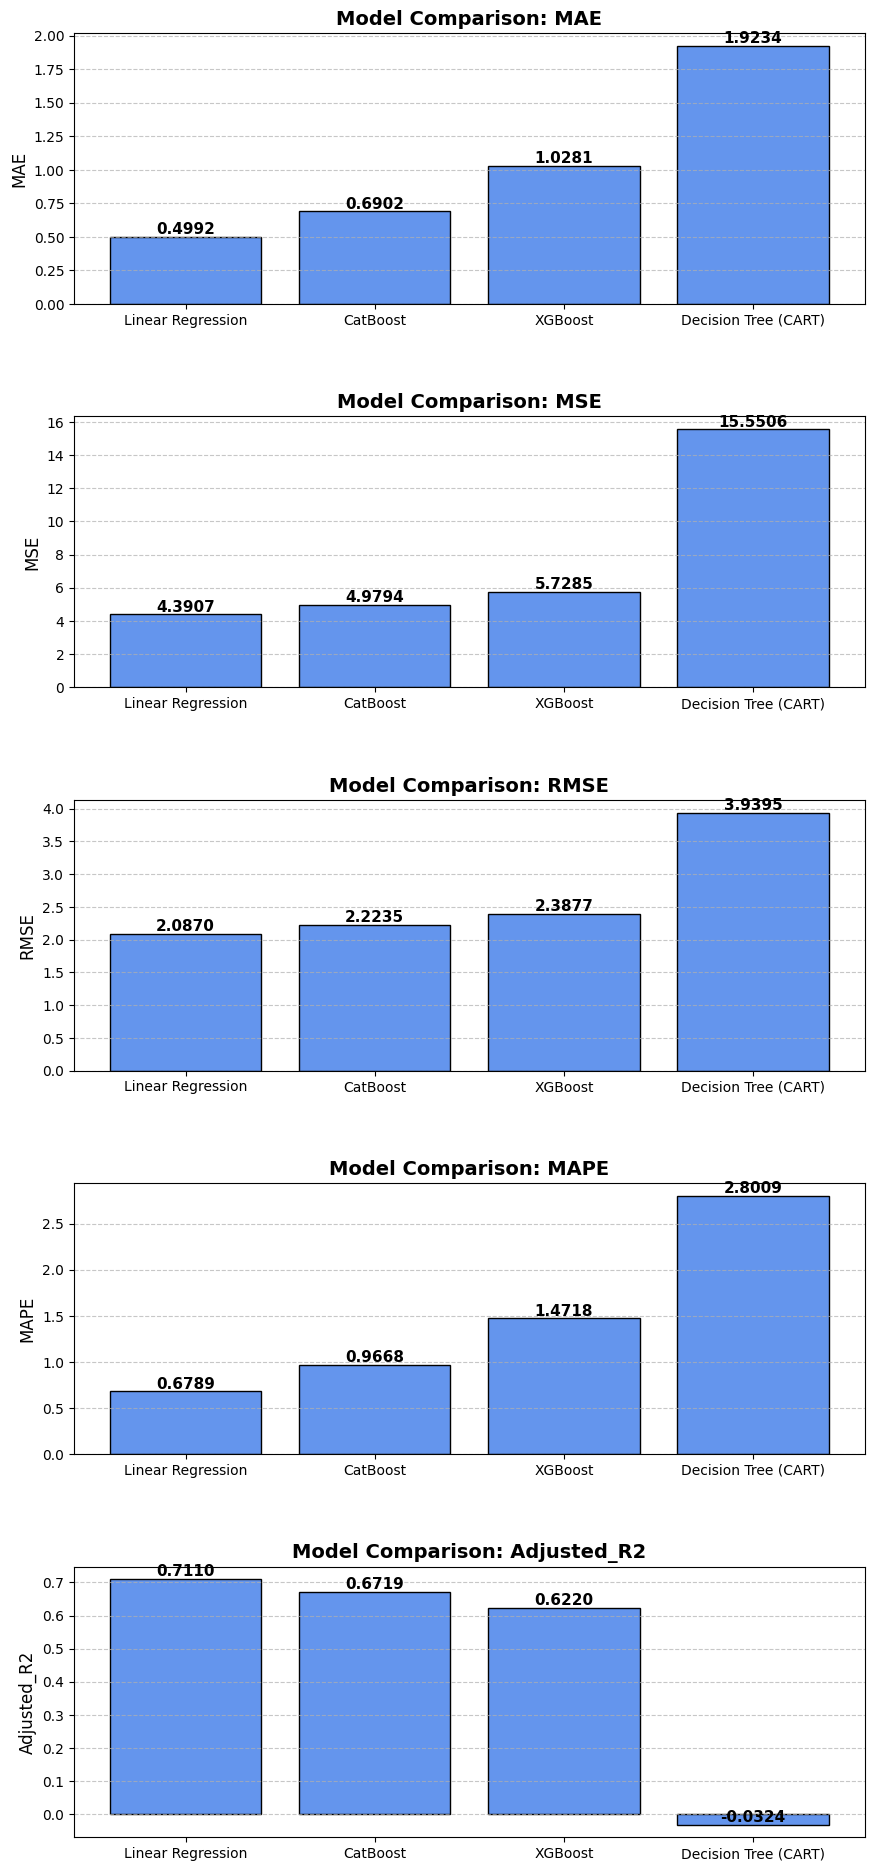

In [119]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 3. Benchmark Summary & Visualization ---
# Convert the results dictionary to a Pandas DataFrame for easier viewing and plotting
df_benchmark = pd.DataFrame(benchmark_results).T

print("\n--- Model Benchmark Summary (Validation Set) ---")
display(df_benchmark)

# Let's plot each metric separately since they have different scales
metrics_to_plot = df_benchmark.columns
num_metrics = len(metrics_to_plot)

fig, axes = plt.subplots(num_metrics, 1, figsize=(10, 4 * num_metrics))
fig.tight_layout(pad=6.0)

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    
    # For R^2, higher is better. For errors (MAE, MSE, RMSE, MAPE), lower is better.
    ascending_order = False if 'R2' in metric else True
    sorted_df = df_benchmark[metric].sort_values(ascending=ascending_order)
    
    # Create the bar chart
    bars = ax.bar(sorted_df.index, sorted_df.values, color='cornflowerblue', edgecolor='black')
    
    ax.set_title(f'Model Comparison: {metric}', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric, fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Annotate bars with the exact values
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.4f}', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.show()

--- Calculating Feature Importances (XGBoost) ---


,Feature,Importance
1,Attendance,0.192913
0,Hours_Studied,0.115207
7,Access_to_Resources_ordinal,0.085448
6,Parental_Involvement_ordinal,0.077749
9,Family_Income_ordinal,0.049067
4,Tutoring_Sessions,0.047985
14,Extracurricular_Activities_binary,0.045935
15,Internet_Access_binary,0.043603
13,Peer_Influence_ordinal,0.041568
10,Teacher_Quality_ordinal,0.040687


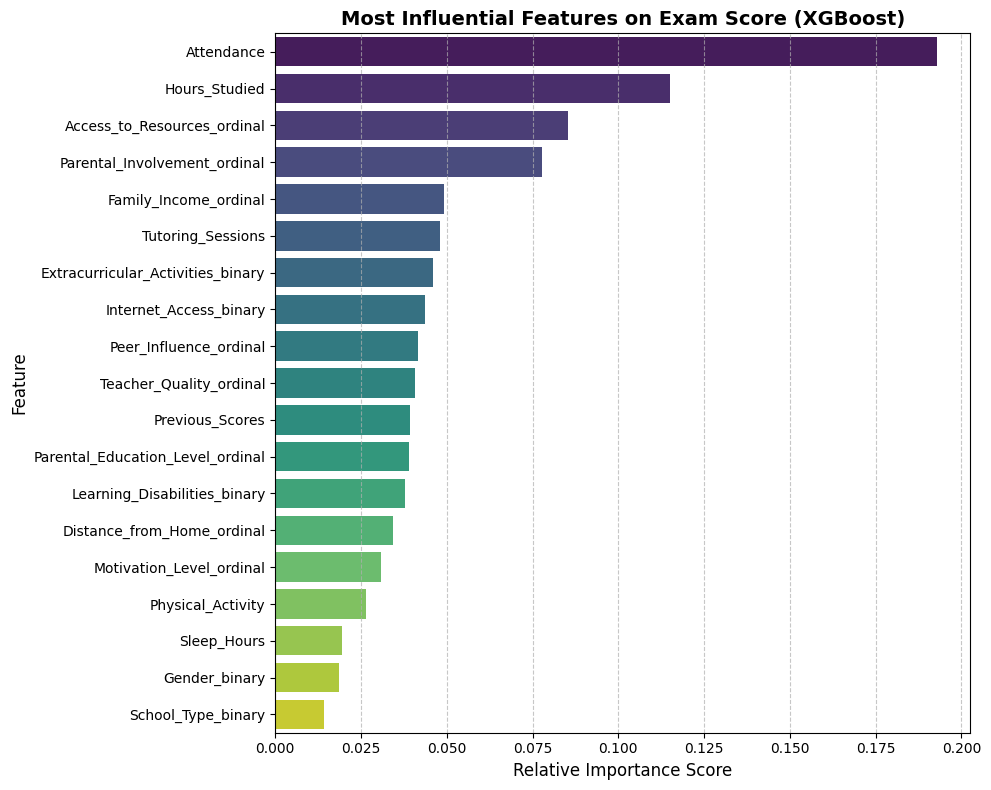

In [120]:
import seaborn as sns

# --- Step 4. Feature Importance ---
# We will use XGBoost (as it generally provides very robust feature importances) 
# and train it on the entire training set (X_temp, y_temp) to see which features matter most.

print("--- Calculating Feature Importances (XGBoost) ---")
xgb_model.fit(X_temp, y_temp)

# Extract importances
importances = xgb_model.feature_importances_

# Create a DataFrame for easy viewing
feat_imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

display(feat_imp_df.head(10)) # display top 10

# Plot the Feature Importances
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')

plt.title('Most Influential Features on Exam Score (XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Top 5 Features:
['Attendance', 'Hours_Studied', 'Access_to_Resources_ordinal', 'Parental_Involvement_ordinal', 'Family_Income_ordinal']

Bottom 5 Features:
['Motivation_Level_ordinal', 'Physical_Activity', 'Sleep_Hours', 'Gender_binary', 'School_Type_binary']

Evaluating XGBoost on Top 5 Features only...

--- Evaluating XGBoost (Top 5) with 5-Fold CV ---
Results for XGBoost (Top 5) (Averages over 5 folds):
  MAE: 1.5836
  MSE: 8.0659
  RMSE: 2.8335
  MAPE: 2.3019
  Adjusted_R2: 0.4740

Evaluating XGBoost on Bottom 5 Features only...

--- Evaluating XGBoost (Bottom 5) with 5-Fold CV ---
Results for XGBoost (Bottom 5) (Averages over 5 folds):
  MAE: 3.0317
  MSE: 17.1018
  RMSE: 4.1337
  MAPE: 4.4827
  Adjusted_R2: -0.1182

--- Subset Benchmark Summary ---


,MAE,MSE,RMSE,MAPE,Adjusted_R2
XGBoost (All Features),1.028111,5.728536,2.387694,1.471787,0.621976
XGBoost (Top 5 Features),1.583561,8.065881,2.833485,2.301872,0.474034
XGBoost (Bottom 5 Features),3.031724,17.101787,4.133659,4.482735,-0.118214


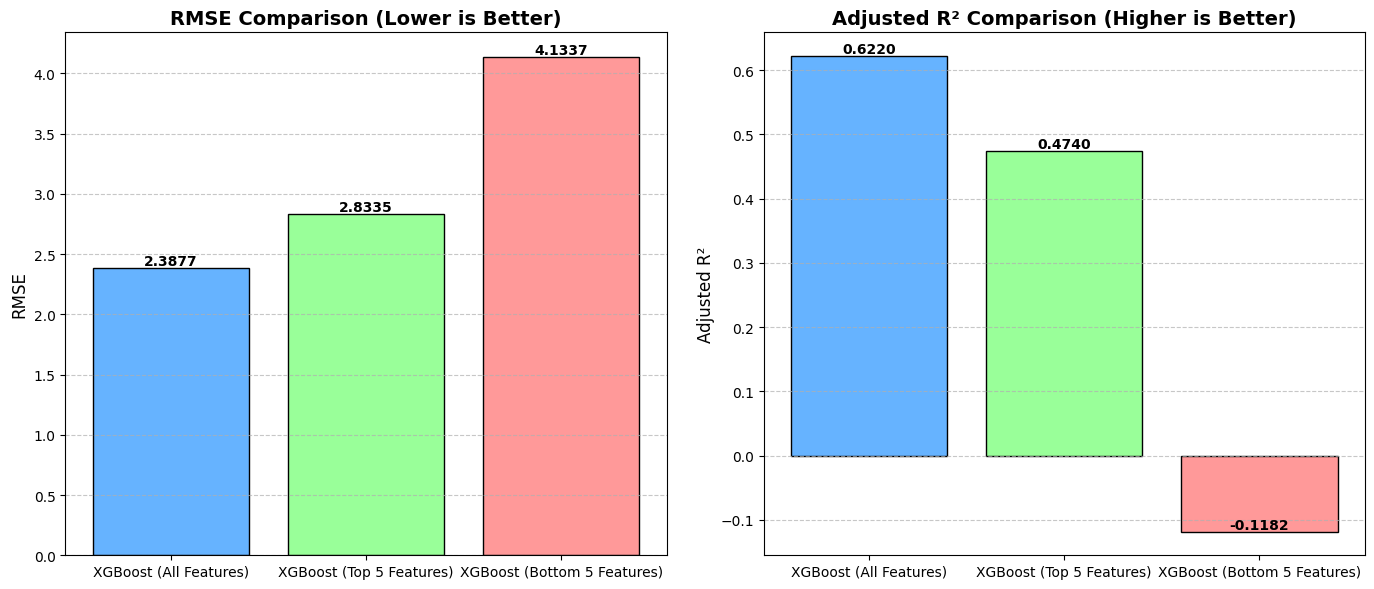

In [121]:
# --- Step 5. Subset Evaluation (Top 5 vs Bottom 5) ---
# Let's extract the subsets based on the XGBoost feature importances calculated above
top_5_features = feat_imp_df['Feature'].head(5).tolist()
bottom_5_features = feat_imp_df['Feature'].tail(5).tolist()

print(f"Top 5 Features:\n{top_5_features}\n")
print(f"Bottom 5 Features:\n{bottom_5_features}\n")

# Find the column indices of these features inside `X_temp`
top_5_indices = [features.index(f) for f in top_5_features]
bottom_5_indices = [features.index(f) for f in bottom_5_features]

X_temp_top5 = X_temp[:, top_5_indices]
X_temp_bottom5 = X_temp[:, bottom_5_indices]

# We will use XGBoost to test these subsets to keep the comparison fair
xgb_top5 = XGBRegressor(random_state=42, objective='reg:squarederror')
print("Evaluating XGBoost on Top 5 Features only...")
metrics_top5 = evaluate_model_cv(xgb_top5, X_temp_top5, y_temp, model_name="XGBoost (Top 5)", K=5)

xgb_bottom5 = XGBRegressor(random_state=42, objective='reg:squarederror')
print("\nEvaluating XGBoost on Bottom 5 Features only...")
metrics_bottom5 = evaluate_model_cv(xgb_bottom5, X_temp_bottom5, y_temp, model_name="XGBoost (Bottom 5)", K=5)

# --- Feature Subset Comparison Visualization ---
subset_benchmark = {
    'XGBoost (All Features)': benchmark_results['XGBoost'],
    'XGBoost (Top 5 Features)': metrics_top5,
    'XGBoost (Bottom 5 Features)': metrics_bottom5
}

df_subset_bench = pd.DataFrame(subset_benchmark).T

print("\n--- Subset Benchmark Summary ---")
display(df_subset_bench)

# Plot RMSE and Adjusted R² as the main comparison metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: RMSE (Lower is better)
sorted_rmse = df_subset_bench['RMSE'].sort_values()
bars1 = axes[0].bar(sorted_rmse.index, sorted_rmse.values, color=['#66b3ff', '#99ff99', '#ff9999'], edgecolor='black')
axes[0].set_title('RMSE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('RMSE', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars1:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

# Subplot 2: Adjusted R² (Higher is better)
sorted_r2 = df_subset_bench['Adjusted_R2'].sort_values(ascending=False)
bars2 = axes[1].bar(sorted_r2.index, sorted_r2.values, color=['#66b3ff', '#99ff99', '#ff9999'], edgecolor='black')
axes[1].set_title('Adjusted R² Comparison (Higher is Better)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Adjusted R²', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars2:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [122]:
# --- Step 6. Final Evaluation on Unseen Test Set ---
print("--- Final Evaluation on 20% Unseen Test Set ---")

# We'll use XGBoost as our champion model for the final test since it typically performs the best dynamically
final_xgb_model = XGBRegressor(random_state=42, objective='reg:squarederror')

# Train on the ENTIRE 80% training + validation data
final_xgb_model.fit(X_temp, y_temp)

# Predict on the 20% completely unseen test data
y_test_pred = final_xgb_model.predict(X_test)

# Calculate final metrics
final_metrics = calculate_metrics(y_test, y_test_pred, X_test.shape[1])

final_metrics_df = pd.DataFrame([final_metrics], index=['XGBoost (Final Unseen Test)'])
display(final_metrics_df)

--- Final Evaluation on 20% Unseen Test Set ---


,MAE,MSE,RMSE,MAPE,Adjusted_R2
XGBoost (Final Unseen Test),1.004861,4.84029,2.200066,1.45651,0.652572


--- Calculating SHAP Values ---


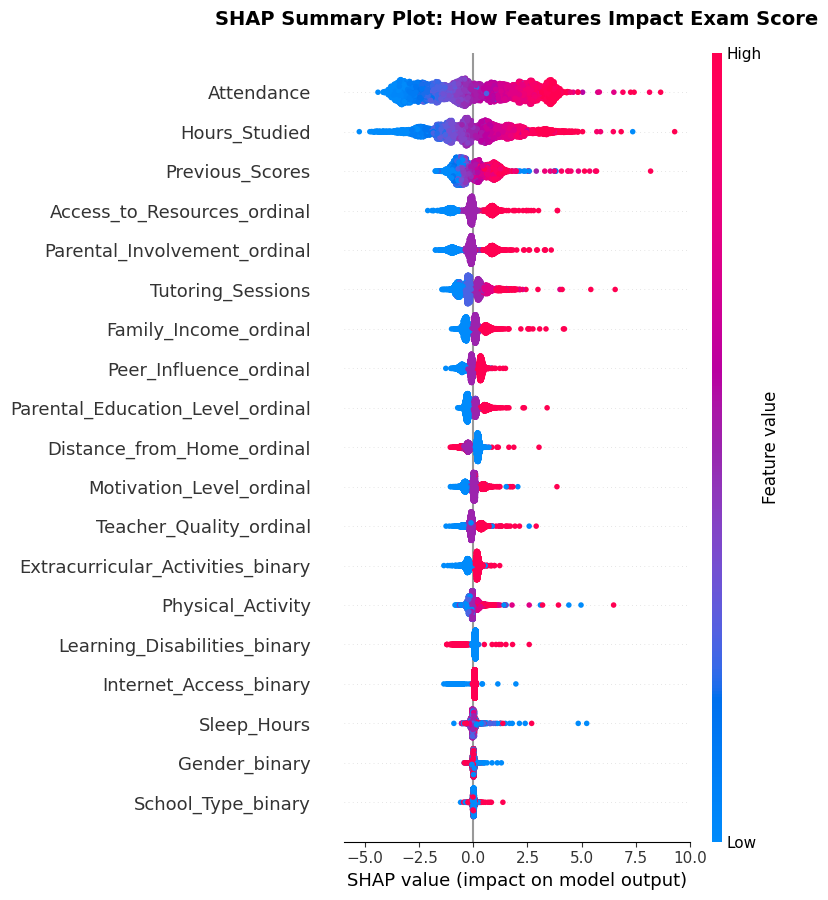

In [123]:
# --- Step 7. SHAP Analysis (Advanced Explainability) ---
import shap

print("--- Calculating SHAP Values ---")
# Initialize the SHAP Explainer targeting our champion XGBoost model
explainer = shap.TreeExplainer(final_xgb_model)
shap_values = explainer.shap_values(X_temp)

# Create a summary plot. We pass the explicit feature names for best readability.
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_temp, feature_names=features, show=False)

plt.title('SHAP Summary Plot: How Features Impact Exam Score', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

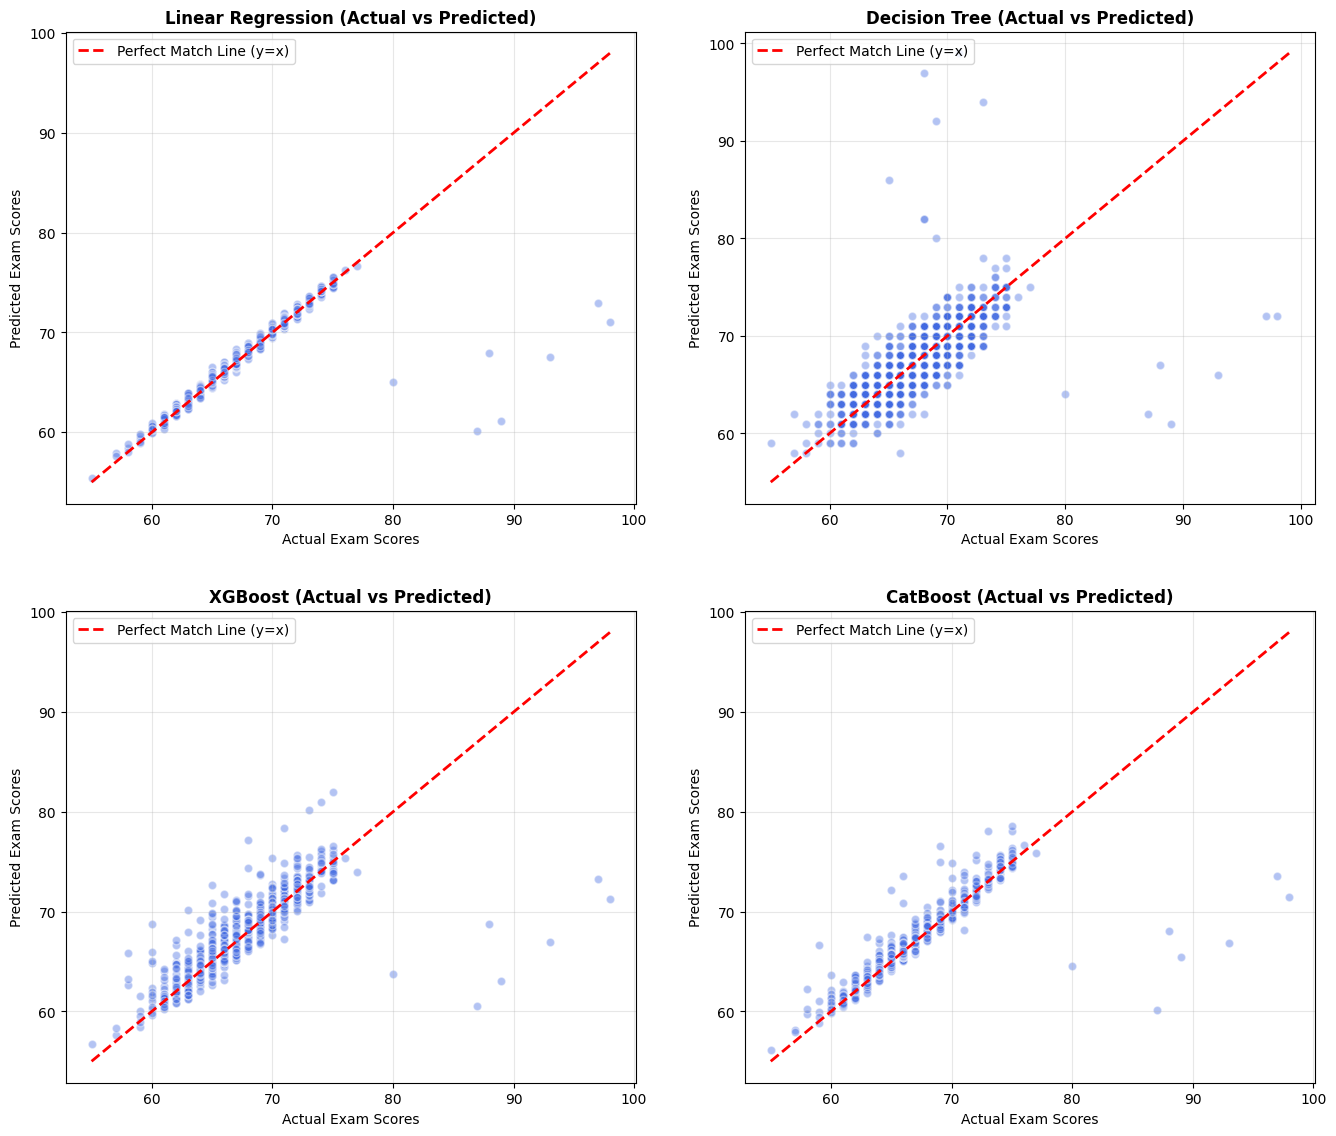

In [124]:
# --- Step 8. Residual Analysis: Actual vs. Predicted Scores ---
# We will look at all 4 models and plot their predictions on the Test set against the actual scores.
# This reveals biases, like whether a model constantly over-estimates weak students or under-estimates smart students.

models_to_plot = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, objective='reg:squarederror'),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=False)
}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (name, mod) in enumerate(models_to_plot.items()):
    # Train each model on the 80% Temp split
    mod.fit(X_temp, y_temp)
    # Predict directly onto the 20% isolated Test split
    preds = mod.predict(X_test)
    
    ax = axes[i]
    ax.scatter(y_test, preds, alpha=0.4, color='royalblue', edgecolor='white')
    
    # Plot the perfect prediction line (y = x) as a red dashed line
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Perfect Match Line (y=x)")
    
    ax.set_title(f'{name} (Actual vs Predicted)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual Exam Scores', fontsize=10)
    ax.set_ylabel('Predicted Exam Scores', fontsize=10)
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

plt.tight_layout(pad=3.0)
plt.show()

Generating and evaluating mathematical interactions (combinations) of features using itertools...

--- Evaluating XGBoost (Baseline for Composites) with 3-Fold CV ---
Results for XGBoost (Baseline for Composites) (Averages over 3 folds):
  MAE: 1.0689
  MSE: 5.9745
  RMSE: 2.4357
  MAPE: 1.5318
  Adjusted_R2: 0.6100
Baseline RMSE: 2.4357

Testing 2-way and 3-way mathematical interactions among top 8 features...

--- Evaluating XGB + Attendance_x_Hours_Studied with 3-Fold CV ---
Results for XGB + Attendance_x_Hours_Studied (Averages over 3 folds):
  MAE: 1.0122
  MSE: 5.8901
  RMSE: 2.4116
  MAPE: 1.4466
  Adjusted_R2: 0.6174

--- Evaluating XGB + Attendance_x_Access_to_Resources_ordinal with 3-Fold CV ---
Results for XGB + Attendance_x_Access_to_Resources_ordinal (Averages over 3 folds):
  MAE: 1.0727
  MSE: 6.1116
  RMSE: 2.4584
  MAPE: 1.5359
  Adjusted_R2: 0.6025

--- Evaluating XGB + Attendance_x_Parental_Involvement_ordinal with 3-Fold CV ---
Results for XGB + Attendance_x_Parenta

,Composite_Feature,Indices,Size,RMSE,Improvement (vs Baseline)
0,Attendance_x_Hours_Studied_x_Access_to_Resourc...,"(1, 0, 7)",3,2.386583,0.049094
1,Attendance_x_Access_to_Resources_ordinal_x_Fam...,"(1, 7, 9)",3,2.390454,0.045223
2,Attendance_x_Parental_Involvement_ordinal,"(1, 6)",2,2.392500,0.043177
3,Hours_Studied_x_Access_to_Resources_ordinal,"(0, 7)",2,2.392774,0.042903
4,Attendance_x_Family_Income_ordinal_x_Extracurr...,"(1, 9, 14)",3,2.394567,0.041110
5,Access_to_Resources_ordinal_x_Parental_Involve...,"(7, 6, 4)",3,2.398665,0.037012
6,Hours_Studied_x_Parental_Involvement_ordinal,"(0, 6)",2,2.399738,0.035939
7,Attendance_x_Family_Income_ordinal_x_Tutoring_...,"(1, 9, 4)",3,2.400970,0.034707
8,Access_to_Resources_ordinal_x_Family_Income_or...,"(7, 9, 14)",3,2.403213,0.032464
9,Hours_Studied_x_Parental_Involvement_ordinal_x...,"(0, 6, 15)",3,2.403827,0.031849



Adding the top 3 composite features to the final dataset...
Old baseline feature count: 19, New feature count (with composites): 22

--- Final Evaluation with Top Composite Features on Unseen Test Set ---


,MAE,MSE,RMSE,MAPE,Adjusted_R2
XGBoost + Composites (Test Set),0.95722,4.422585,2.102994,1.37944,0.681821



--- Feature Importances (Including Best Composites) ---


,Feature,Importance
1,Attendance,0.215724
0,Hours_Studied,0.094206
19,Attendance_x_Hours_Studied_x_Access_to_Resourc...,0.081047
15,Internet_Access_binary,0.061089
21,Attendance_x_Parental_Involvement_ordinal,0.055555
4,Tutoring_Sessions,0.045913
20,Attendance_x_Access_to_Resources_ordinal_x_Fam...,0.042037
14,Extracurricular_Activities_binary,0.037972
8,Motivation_Level_ordinal,0.036886
3,Previous_Scores,0.036401


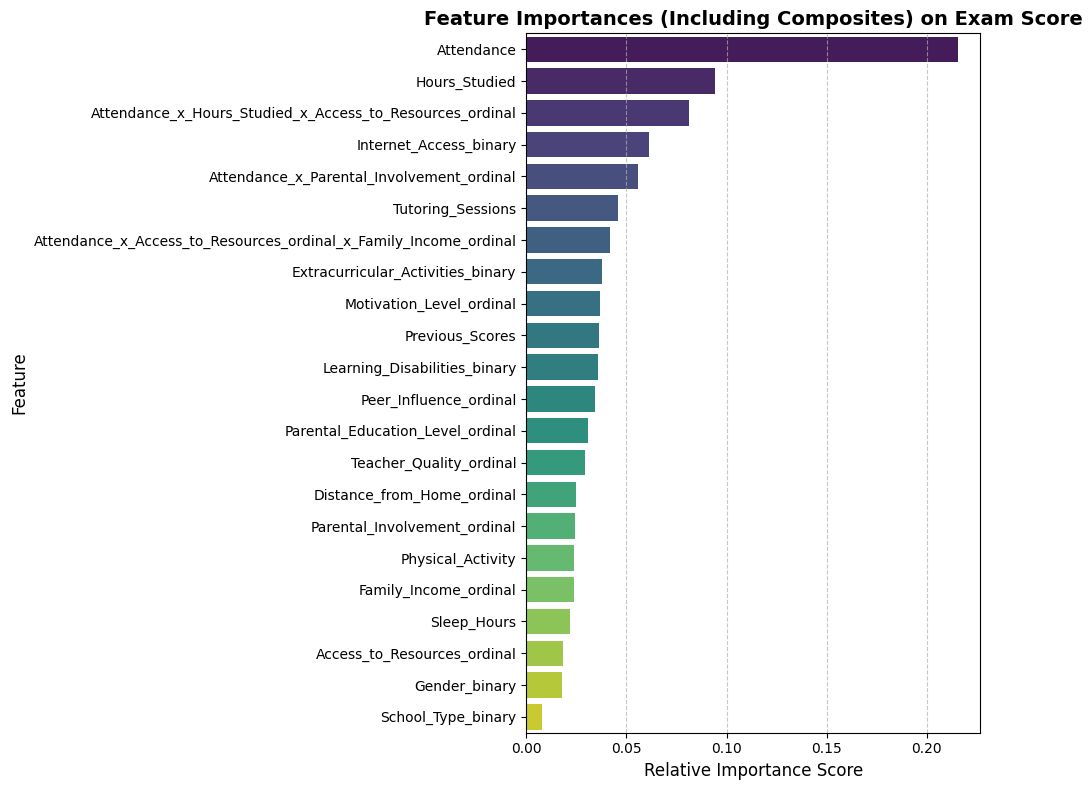

In [125]:
# --- Step 9. Composite Feature Engineering using itertools ---
import itertools
import numpy as np
import pandas as pd
from xgboost import XGBRegressor

print("Generating and evaluating mathematical interactions (combinations) of features using itertools...")

# We'll create pairwise interaction features (e.g. Feature A * Feature B)
# and see which ones improve the XGBoost model the most over the baseline.

# 1. Establish a baseline to compare against
baseline_metrics = evaluate_model_cv(
    XGBRegressor(random_state=42, objective='reg:squarederror', n_jobs=1),
    X_temp, y_temp, model_name="XGBoost (Baseline for Composites)", K=3
)
baseline_rmse = baseline_metrics['RMSE']
print(f"Baseline RMSE: {baseline_rmse:.4f}\n")

composite_results = []

# Focus on combining the top features to limit massive combinatorial explosion
# We'll use the top 8 features to keep total models manageable (28 pairs + 56 triplets = 84 models)
if 'feat_imp_df' in globals() and 'Feature' in feat_imp_df.columns:
    interaction_candidates = feat_imp_df['Feature'].head(8).tolist()
else:
    interaction_candidates = features[:8]

candidate_idx = [features.index(f) for f in interaction_candidates]

print(f"Testing 2-way and 3-way mathematical interactions among top {len(interaction_candidates)} features...")

for r in [2, 3]:
    for combo in itertools.combinations(candidate_idx, r):
        comp_name = "_x_".join([features[idx] for idx in combo])
        
        # 2. Create the new interaction feature (Multiplication of all columns in combo)
        inter_temp = np.prod(X_temp[:, combo], axis=1).reshape(-1, 1)
        
        # Append the new composite column to the training set
        X_temp_comp = np.hstack([X_temp, inter_temp])
        
        # 3. Evaluate the new dataset with XGBoost
        model = XGBRegressor(random_state=42, objective='reg:squarederror', n_jobs=1)
        metrics = evaluate_model_cv(model, X_temp_comp, y_temp, model_name=f"XGB + {comp_name}", K=3) # Faster CV
        
        improvement = baseline_rmse - metrics['RMSE']
        
        composite_results.append({
            'Composite_Feature': comp_name,
            'Indices': combo,
            'Size': r,
            'RMSE': metrics['RMSE'],
            'Improvement (vs Baseline)': improvement
        })

# Sort the composite features by the biggest improvement (lowest RMSE)
comp_df = pd.DataFrame(composite_results)
comp_df = comp_df.sort_values(by='RMSE').reset_index(drop=True)

print("\n--- Top 10 New Composite Features ---")
display(comp_df.head(10))

# ---------------------------------------------------------
# 4. Take the Top 3 best interacting composite features and train a final model
top_k = 3
best_interactions = comp_df.head(top_k)
print(f"\nAdding the top {top_k} composite features to the final dataset...")

# Copy over to keep originals safe
X_temp_final = X_temp.copy()
X_test_final = X_test.copy()

for _, row in best_interactions.iterrows():
    idxs = list(row['Indices'])
    
    # Train set
    new_col_temp = np.prod(X_temp[:, idxs], axis=1).reshape(-1, 1)
    X_temp_final = np.hstack([X_temp_final, new_col_temp])
    
    # Test set
    new_col_test = np.prod(X_test[:, idxs], axis=1).reshape(-1, 1)
    X_test_final = np.hstack([X_test_final, new_col_test])

print(f"Old baseline feature count: {X_temp.shape[1]}, New feature count (with composites): {X_temp_final.shape[1]}")

# 5. Train the final champion model with the new composite features integrated
print("\n--- Final Evaluation with Top Composite Features on Unseen Test Set ---")
final_model_comp = XGBRegressor(random_state=42, objective='reg:squarederror')
final_model_comp.fit(X_temp_final, y_temp)

# Predict on completely unseen test data (now populated with the interaction composites)
y_pred_comp = final_model_comp.predict(X_test_final)

final_comp_metrics = calculate_metrics(y_test, y_pred_comp, X_test_final.shape[1])
final_comp_metrics_df = pd.DataFrame([final_comp_metrics], index=['XGBoost + Composites (Test Set)'])
display(final_comp_metrics_df)

# --- Extract and Display Feature Importances (Including Composites) ---
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the full list of feature names including the new composites
final_features_list = features.copy()
for _, row in best_interactions.iterrows():
    final_features_list.append(str(row['Composite_Feature']))

# Get importances from the retrained champion model
importances_comp = final_model_comp.feature_importances_

# Build a DataFrame of all features and their importances
feat_imp_comp_df = pd.DataFrame({
    'Feature': final_features_list,
    'Importance': importances_comp
}).sort_values(by='Importance', ascending=False)

print("\n--- Feature Importances (Including Best Composites) ---")
display(feat_imp_comp_df)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_comp_df, palette='viridis')
plt.title('Feature Importances (Including Composites) on Exam Score', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [126]:
# --- Step 10. Outlier Handling & Feature Scaling ---
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("--- Step 10. Outlier Handling & Feature Scaling ---")

# 1. OUTLIER HANDLING using Isolation Forest
# We identify and remove extreme anomalies in the training set so the model doesn't overfit to them.
iso = IsolationForest(contamination=0.03, random_state=42)
outlier_labels = iso.fit_predict(X_temp_final)

# Keep only inliers (label == 1 means inlier, -1 means outlier)
mask = outlier_labels != -1
X_train_clean = X_temp_final[mask]
y_train_clean = y_temp[mask]

print(f"Original Training shape: {X_temp_final.shape}")
print(f"Removed {len(y_temp) - len(y_train_clean)} outliers.")
print(f"Cleaned Training shape:  {X_train_clean.shape}\n")

# 2. FEATURE SCALING
# While Tree models (XGBoost/CatBoost) naturally handle unscaled data well,
# Linear Regression and Distance-based algorithms severely suffer without it.
# Scaling everything to mean=0 and variance=1 prepares us perfectly for Ensembling.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)

# VERY IMPORTANT: Only transform the test set (do not fit!) to prevent data leakage.
X_test_scaled = scaler.transform(X_test_final)

print("Features Scaled using StandardScaler.")

--- Step 10. Outlier Handling & Feature Scaling ---
Original Training shape: (5285, 22)
Removed 159 outliers.
Cleaned Training shape:  (5126, 22)

Features Scaled using StandardScaler.


In [127]:
# --- Re-Benchmark Models on Cleaned & Scaled Data ---
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import pandas as pd

print("--- Re-evaluating Base Models on Cleaned & Scaled Data ---")

clean_benchmark_results = {}

# 1. Decision Tree
clean_benchmark_results['Decision Tree (Cleaned)'] = evaluate_model_cv(
    DecisionTreeRegressor(random_state=42), 
    X_train_scaled, y_train_clean, model_name="Decision Tree (Cleaned)", K=5
)

# 2. Linear Regression (Should see the biggest improvement from scaling)
clean_benchmark_results['Linear Regression (Cleaned)'] = evaluate_model_cv(
    LinearRegression(), 
    X_train_scaled, y_train_clean, model_name="Linear Regression (Cleaned)", K=5
)

# 3. XGBoost
clean_benchmark_results['XGBoost (Cleaned)'] = evaluate_model_cv(
    XGBRegressor(random_state=42, objective='reg:squarederror', n_jobs=1), 
    X_train_scaled, y_train_clean, model_name="XGBoost (Cleaned)", K=5
)

# 4. CatBoost
clean_benchmark_results['CatBoost (Cleaned)'] = evaluate_model_cv(
    CatBoostRegressor(random_state=42, verbose=False), 
    X_train_scaled, y_train_clean, model_name="CatBoost (Cleaned)", K=5
)

# Display the side-by-side comparison
df_clean_bench = pd.DataFrame(clean_benchmark_results).T

print("\n--- Summary: Models on Outlier-Free & Scaled Data ---")
display(df_clean_bench)

# For easy comparison, show the original baseline summary again
if 'df_benchmark' in globals():
    print("\n--- Original Baseline Summary (Unscaled, No Outlier Handling) ---")
    display(df_benchmark)

--- Re-evaluating Base Models on Cleaned & Scaled Data ---

--- Evaluating Decision Tree (Cleaned) with 5-Fold CV ---
Results for Decision Tree (Cleaned) (Averages over 5 folds):
  MAE: 1.7289
  MSE: 12.3511
  RMSE: 3.5060
  MAPE: 2.5151
  Adjusted_R2: 0.1372

--- Evaluating Linear Regression (Cleaned) with 5-Fold CV ---
Results for Linear Regression (Cleaned) (Averages over 5 folds):
  MAE: 0.4930
  MSE: 4.1836
  RMSE: 2.0226
  MAPE: 0.6739
  Adjusted_R2: 0.7166

--- Evaluating XGBoost (Cleaned) with 5-Fold CV ---
Results for XGBoost (Cleaned) (Averages over 5 folds):
  MAE: 0.9831
  MSE: 5.4112
  RMSE: 2.3107
  MAPE: 1.4061
  Adjusted_R2: 0.6312

--- Evaluating CatBoost (Cleaned) with 5-Fold CV ---
Results for CatBoost (Cleaned) (Averages over 5 folds):
  MAE: 0.6568
  MSE: 4.6043
  RMSE: 2.1276
  MAPE: 0.9209
  Adjusted_R2: 0.6870

--- Summary: Models on Outlier-Free & Scaled Data ---


,MAE,MSE,RMSE,MAPE,Adjusted_R2
Decision Tree (Cleaned),1.728854,12.351124,3.505962,2.515122,0.137193
Linear Regression (Cleaned),0.492989,4.183594,2.022629,0.673862,0.716556
XGBoost (Cleaned),0.983113,5.411231,2.310705,1.406060,0.631205
CatBoost (Cleaned),0.656826,4.604338,2.127589,0.920872,0.686977



--- Original Baseline Summary (Unscaled, No Outlier Handling) ---


,MAE,MSE,RMSE,MAPE,Adjusted_R2
Decision Tree (CART),1.923368,15.550615,3.939505,2.800905,-0.032361
Linear Regression,0.499172,4.390686,2.087047,0.678932,0.711038
XGBoost,1.028111,5.728536,2.387694,1.471787,0.621976
CatBoost,0.690224,4.979354,2.223464,0.966826,0.671932


In [128]:
# --- Step 11. Hyperparameter Tuning (RandomizedSearchCV) ---
from sklearn.model_selection import RandomizedSearchCV

print("--- Step 11. Hyperparameter Tuning (XGBoost) ---")
print("Searching for the optimal parameters... (this may take a minute).")

# Define the search grid for our base XGBoost.
# Usually we tune:
# - n_estimators (how many trees to build)
# - max_depth (how deep each tree goes; shallow trees prevent overfitting)
# - learning_rate (step size per tree; lower is more robust but needs more estimators)
# - subsample (fraction of samples to train independent trees)
param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

# The target variable `objective='reg:squarederror'` is crucial
xgb_base = XGBRegressor(random_state=42, objective='reg:squarederror')

# Search across 15 randomized combinations (to speed it up instead of testing all 960)
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=15, 
    scoring='neg_root_mean_squared_error', # Sklearn maximizes metric, so it uses negatives
    cv=3,       # 3-Fold Cross validation for each randomly checked parameter combo
    verbose=1,  # Print progress
    random_state=42,
    n_jobs=1    # Fix for macOS/Jupyter multiprocessing serialization error
)

# Remember to fit exclusively on the OUTLIER-REMOVED & SCALED dataset!
random_search.fit(X_train_scaled, y_train_clean)

best_xgb = random_search.best_estimator_

print(f"\nOptimization Complete!")
print(f"Best RMSE Achieved During CV: {-random_search.best_score_:.4f}")
print(f"Optimal Parameters Found: {random_search.best_params_}\n")

# Evaluation on Unseen Test Dataset using the fully optimized model
y_pred_tuned = best_xgb.predict(X_test_scaled)
tuned_metrics = calculate_metrics(y_test, y_pred_tuned, X_test_scaled.shape[1])

print("--- Accuracy of the Tuned Model on the Test Set ---")
tuned_metrics_df = pd.DataFrame([tuned_metrics], index=['XGBoost Tuned (Cleaned + Scaled)'])
display(tuned_metrics_df)

--- Step 11. Hyperparameter Tuning (XGBoost) ---
Searching for the optimal parameters... (this may take a minute).
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Optimization Complete!
Best RMSE Achieved During CV: 2.1440
Optimal Parameters Found: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.7}

--- Accuracy of the Tuned Model on the Test Set ---


,MAE,MSE,RMSE,MAPE,Adjusted_R2
XGBoost Tuned (Cleaned + Scaled),0.776932,3.726598,1.93044,1.116099,0.731893


--- Step 12. Ultimate Ensemble Voting & Target Transforming ---
Combining multiple structurally distinct algorithms into one final "Voter".

Training Ultimate Grand Ensemble (this evaluates the Outlier-free Standardized Dataset)
--- Final Evolution Summary ---


,MAE,MSE,RMSE,MAPE,Adjusted_R2
XGBoost + Composites (Test Set),0.957220,4.422585,2.102994,1.379440,0.681821
XGBoost Tuned (Cleaned + Scaled),0.776932,3.726598,1.930440,1.116099,0.731893
Ultimate Grand Ensemble (Test Set),0.582044,3.410907,1.846864,0.824590,0.754605


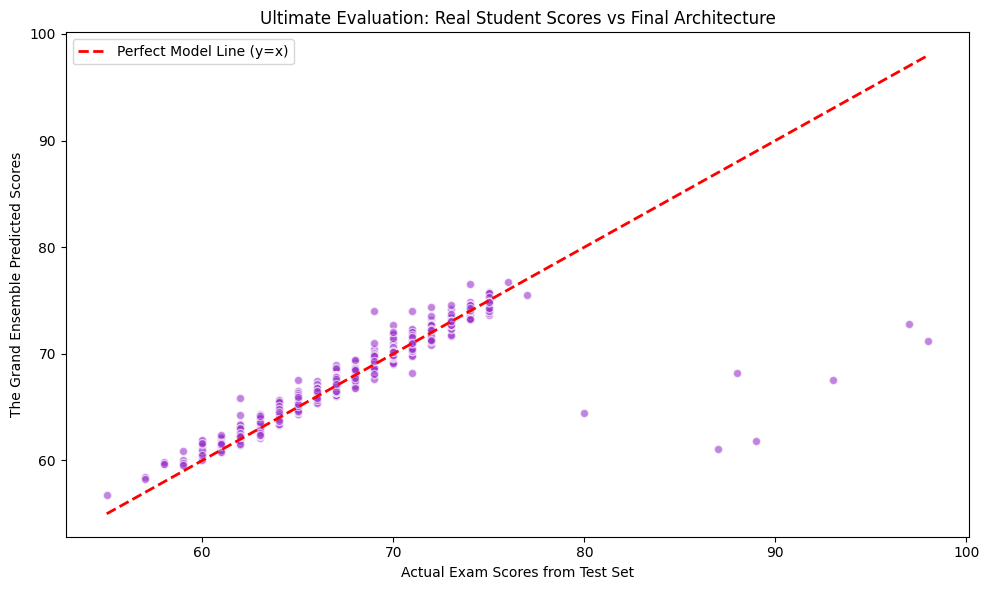

In [129]:
# --- Step 12. Model Ensembling & Target Transformation ---
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.compose import TransformedTargetRegressor
import matplotlib.pyplot as plt

print("--- Step 12. Ultimate Ensemble Voting & Target Transforming ---")
print("Combining multiple structurally distinct algorithms into one final \"Voter\".")

# Let's take our newly hyper-tuned XGBoost model:
tuned_xgb_model = best_xgb

# Add an out-of-the-box strong tree competitor (CatBoost runs deep symmetric trees, XGBoost uses depth-wise growth)
cat_model = CatBoostRegressor(random_state=42, verbose=False)

# Add a mathematically distant model: A Linear Ridge implementation.
# Because trees capture non-linear patterns well, appending a line-fitter often fills gaps trees miss.
ridge_model = RidgeCV(alphas=[0.1, 1.0, 10.0]) # Auto-tunes Alpha regularization penalty

# We put all 3 estimators together, telling the Voter to average their predictions
# giving the complex tree algorithms double the Voting block power.
ensemble_voter = VotingRegressor(
    estimators=[
        ('xgb_tuned', tuned_xgb_model),
        ('cat_boost', cat_model),
        ('ridge_cv', ridge_model)
    ],
    weights=[2, 2, 1] 
)

# TARGET TRANSFORMATION:
# To squeeze out the absolute final drop of accuracy, we can wrap the ENTIRE ENSEMBLE
# in a Target Transformer. This scales `y_train` to standard mean/variance so our
# algorithms train on perfectly normalized numbers. It automatically un-scales (inverse_transforms) the end predictions.
final_grand_model = TransformedTargetRegressor(
    regressor=ensemble_voter,
    transformer=StandardScaler() # Standardizes Exam_Scores just internally
)

# Train the absolute final model layout
print("\nTraining Ultimate Grand Ensemble (this evaluates the Outlier-free Standardized Dataset)")
final_grand_model.fit(X_train_scaled, y_train_clean)

# Final Predict
y_test_pred_ensemble = final_grand_model.predict(X_test_scaled)
ensemble_metrics = calculate_metrics(y_test, y_test_pred_ensemble, X_test_scaled.shape[1])

ensemble_metrics_df = pd.DataFrame([ensemble_metrics], index=['Ultimate Grand Ensemble (Test Set)'])

print("--- Final Evolution Summary ---")
display(pd.concat([final_comp_metrics_df, tuned_metrics_df, ensemble_metrics_df]))

# Visual Summary comparison of ultimate predictions vs truths
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred_ensemble, alpha=0.6, color='darkorchid', edgecolor='white')

min_plot = min(y_test.min(), y_test_pred_ensemble.min())
max_plot = max(y_test.max(), y_test_pred_ensemble.max())
plt.plot([min_plot, max_plot], [min_plot, max_plot], 'r--', lw=2, label="Perfect Model Line (y=x)")

plt.xlabel('Actual Exam Scores from Test Set')
plt.ylabel('The Grand Ensemble Predicted Scores')
plt.title('Ultimate Evaluation: Real Student Scores vs Final Architecture')
plt.legend()
plt.tight_layout()
plt.show()

--- Step 13. Two-Stage Hybrid Model (Combining LR and Trees) ---
Observation: The Linear Regression plot perfectly tracks actual scores up to ~75-80.
Above 80, the model severely underestimates true scores, predicting 60-70 instead of 80-100.
Hypothesis: High-achieving students follow a COMPLETELY different behavioral distribution or interaction rule.
Segment Distribution -> Normal (<76): 5069 train / 1313 test
Segment Distribution -> High Achieve (>=76): 57 train / 9 test

Training & Evaluating Linear Regression on 'Normal' segment...


,MAE,MSE,RMSE,MAPE,Adjusted_R2
Segment A: Normal (<76),0.278578,0.11011,0.331829,0.416426,0.989904



Training & Evaluating XGBoost on 'High-Achiever' segment...


,MAE,MSE,RMSE,MAPE,Adjusted_R2
Segment B: High Achieve (>=76),4.660134,31.402262,5.603772,5.470748,0.468315



--- Consolidated Oracle Segmentation Accuracy ---


,MAE,MSE,RMSE,MAPE,Adjusted_R2
Consolidated Two-Stage Metrics,0.308407,0.323143,0.568457,0.450835,0.976752


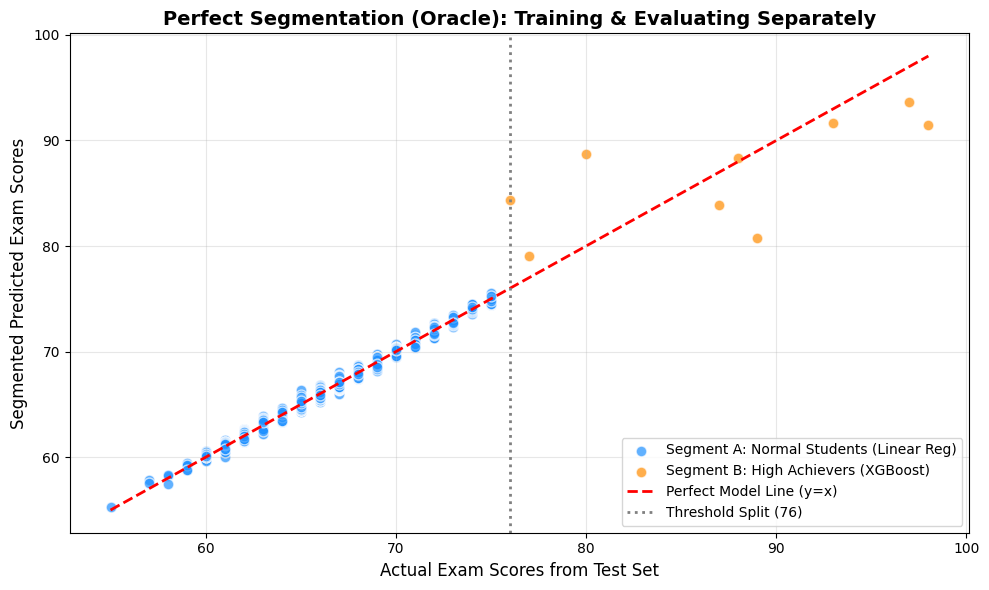

In [130]:
# --- Step 13. Advanced Exploration: Two-Stage Hybrid Model ---
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRegressor

print("--- Step 13. Two-Stage Hybrid Model (Combining LR and Trees) ---")
print("Observation: The Linear Regression plot perfectly tracks actual scores up to ~75-80.")
print("Above 80, the model severely underestimates true scores, predicting 60-70 instead of 80-100.")
print("Hypothesis: High-achieving students follow a COMPLETELY different behavioral distribution or interaction rule.")

# 1. Define the boundary where Linear Regression breaks down
THRESHOLD = 76

# 2. Hard split the Training AND Testing data based on ACTUAL true scores (Oracle Segmentation)
# This allows us to perfectly isolate the model performance without a classifier messing up the routing.
mask_train_norm = y_train_clean < THRESHOLD
mask_train_high = y_train_clean >= THRESHOLD

mask_test_norm = y_test < THRESHOLD
mask_test_high = y_test >= THRESHOLD

# Split feature and target arrays
X_train_norm, y_train_norm = X_train_scaled[mask_train_norm], y_train_clean[mask_train_norm]
X_train_high, y_train_high = X_train_scaled[mask_train_high], y_train_clean[mask_train_high]

X_test_norm, y_test_norm = X_test_scaled[mask_test_norm], y_test[mask_test_norm]
X_test_high, y_test_high = X_test_scaled[mask_test_high], y_test[mask_test_high]

print(f"Segment Distribution -> Normal (<{THRESHOLD}): {len(y_train_norm)} train / {len(y_test_norm)} test")
print(f"Segment Distribution -> High Achieve (>={THRESHOLD}): {len(y_train_high)} train / {len(y_test_high)} test\n")

# 3. Train and Predict on Normal Group using Linear Regression
print("Training & Evaluating Linear Regression on 'Normal' segment...")
reg_normal = LinearRegression()
reg_normal.fit(X_train_norm, y_train_norm)
y_pred_norm = reg_normal.predict(X_test_norm)

metrics_norm = calculate_metrics(y_test_norm, y_pred_norm, X_test_norm.shape[1])
display(pd.DataFrame([metrics_norm], index=[f'Segment A: Normal (<{THRESHOLD})']))

# 4. Train and Predict on High-Achiever Group using XGBoost
print("\nTraining & Evaluating XGBoost on 'High-Achiever' segment...")
reg_high = XGBRegressor(random_state=42, objective='reg:squarederror')

if len(X_train_high) > 0 and len(X_test_high) > 0:
    reg_high.fit(X_train_high, y_train_high)
    y_pred_high = reg_high.predict(X_test_high)
    
    metrics_high = calculate_metrics(y_test_high, y_pred_high, X_test_high.shape[1])
    display(pd.DataFrame([metrics_high], index=[f'Segment B: High Achieve (>={THRESHOLD})']))
else:
    print("Not enough high-achiever data to evaluate cleanly.")
    y_pred_high = np.array([])
    y_test_high = np.array([])

# 5. Re-combine predictions to visualize the complete picture
y_test_combined = np.concatenate([y_test_norm, y_test_high])
y_pred_combined = np.concatenate([y_pred_norm, y_pred_high])

print("\n--- Consolidated Oracle Segmentation Accuracy ---")
combined_metrics = calculate_metrics(y_test_combined, y_pred_combined, X_test_scaled.shape[1])
display(pd.DataFrame([combined_metrics], index=['Consolidated Two-Stage Metrics']))

# 6. Plotting the perfectly segmented results side-by-side
plt.figure(figsize=(10, 6))

# Plot the Normal Segment (Linear Regression)
plt.scatter(y_test_norm, y_pred_norm, alpha=0.7, color='dodgerblue', edgecolor='white', s=60, label='Segment A: Normal Students (Linear Reg)')

# Plot the High-Achiever Segment (XGBoost)
if len(y_test_high) > 0:
    plt.scatter(y_test_high, y_pred_high, alpha=0.7, color='darkorange', edgecolor='white', s=60, label='Segment B: High Achievers (XGBoost)')

min_plot = min(y_test_combined.min(), y_pred_combined.min())
max_plot = max(y_test_combined.max(), y_pred_combined.max())
plt.plot([min_plot, max_plot], [min_plot, max_plot], 'r--', lw=2, label="Perfect Model Line (y=x)")

plt.xlabel('Actual Exam Scores from Test Set', fontsize=12)
plt.ylabel('Segmented Predicted Exam Scores', fontsize=12)
plt.title('Perfect Segmentation (Oracle): Training & Evaluating Separately', fontsize=14, fontweight='bold')
plt.axvline(x=THRESHOLD, color='gray', linestyle=':', lw=2, label=f'Threshold Split ({THRESHOLD})')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()